In [1]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores

In [2]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  

In [5]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

restric_norm = x_scaler.transform(Restrictions_data)
print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])



Shape de Restrictions_data: (2145, 2)
Primeiras linhas de Restrictions_data:
 [[0.16327083 0.0938734 ]
 [0.24245778 0.17594412]
 [0.32163697 0.25801016]
 [0.40079243 0.34006069]
 [0.47989594 0.42207508]]
(2145, 2)

Ajustando os normalizadores (scalers) com os dados de treino...
Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'

Shape de Restrictions_data normalizado: (2145, 2)

Shape de X_train depois da normalização: (2145, 2)
Primeiras linhas de X_train normalizado:
 [[0.84617662 0.86253703]
 [0.85097515 0.86788632]
 [0.85574195 0.87320305]
 [0.86044886 0.87845795]
 [0.86507184 0.8836256 ]]

Primeiras linhas de y_train normalizado:
 [[0.07529811]
 [0.07527054]
 [0.07519498]
 [0.07504621]
 [0.07479823]]


In [12]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1.0, λ2=0
Epoch 1: Loss=0.1252, MSE_d=0.1252, MSE_f=0.1254, Val MSE=0.1382
Epoch 500: Loss=0.06388, MSE_d=0.06388, MSE_f=0.06551, Val MSE=0.1132
Epoch 1000: Loss=0.0607, MSE_d=0.0607, MSE_f=0.06232, Val MSE=0.1103
Early stopping na época 1281

Training Metrics:
  R2: 0.2098
  MSE: 0.06085
  RMSE: 0.2467
  MAPE: 3.058

Validation Metrics:
  R2: 0.2078
  MSE: 0.1103
  RMSE: 0.3321
  MAPE: 3.46

Test Metrics:
  R2: 0.07378
  MSE: 0.05027
  RMSE: 0.2242
  MAPE: 1.117
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


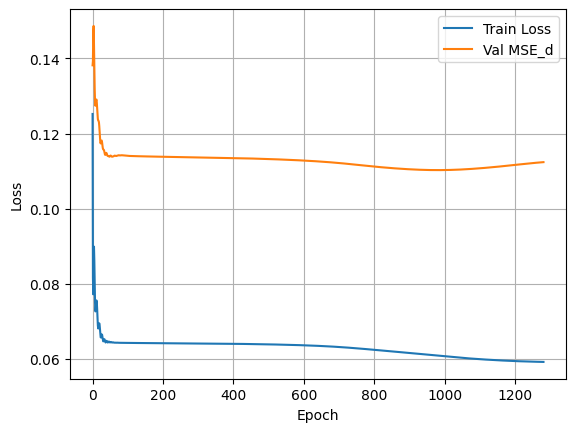

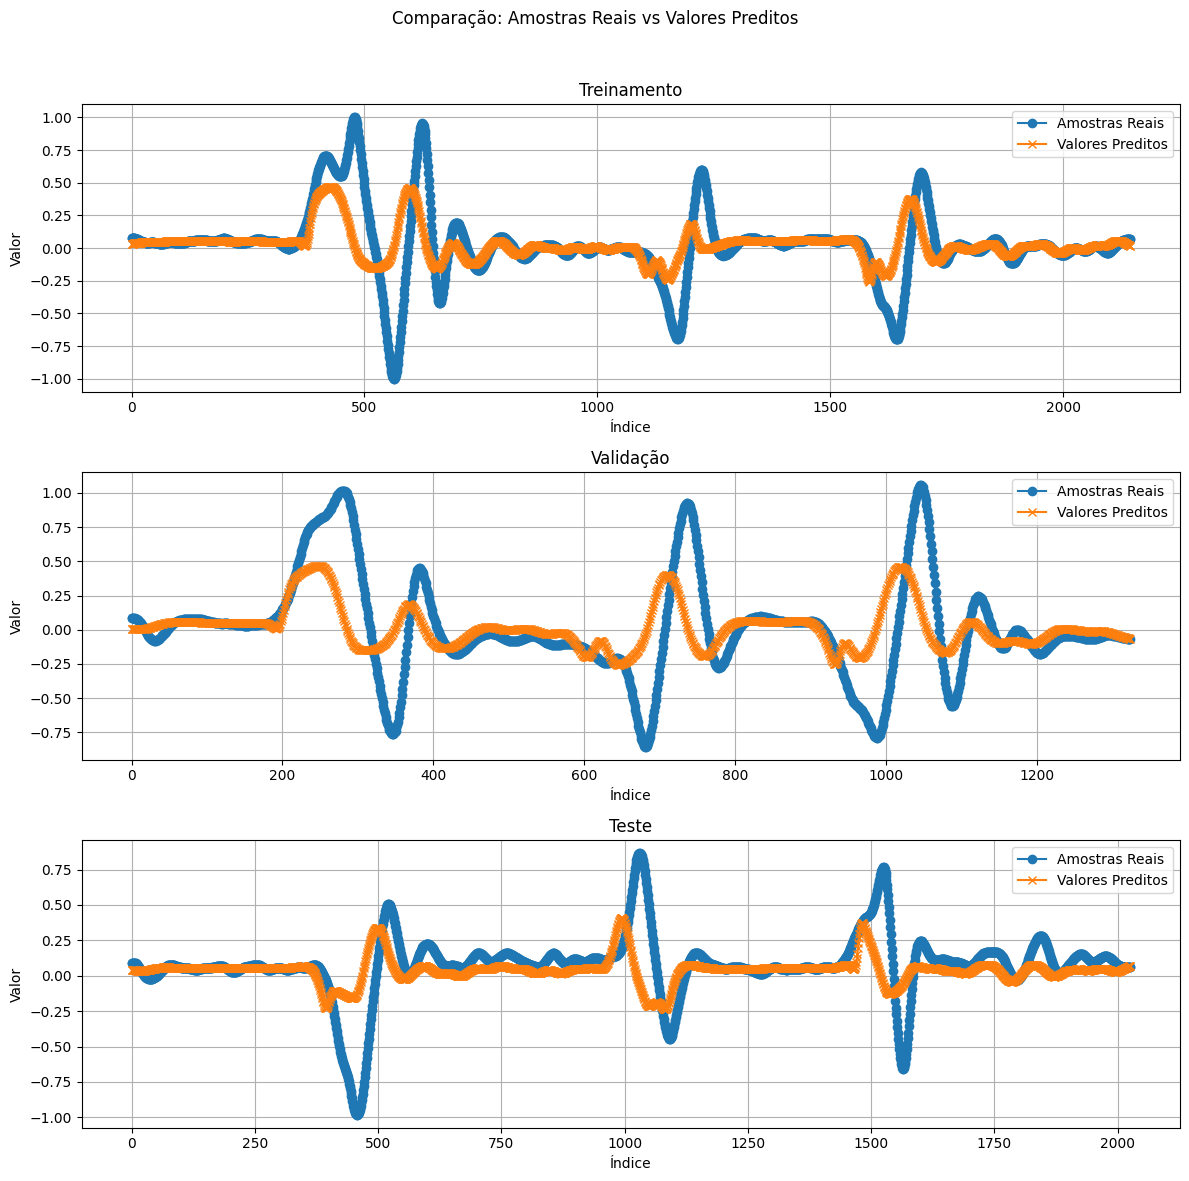

{'Training': {'R2': 0.2097967267036438,
  'MSE': 0.060853827744722366,
  'RMSE': 0.2466856861366755,
  'MAPE': 3.0577094554901123},
 'Validation': {'R2': 0.20779293775558472,
  'MSE': 0.11027712374925613,
  'RMSE': 0.33207999600887755,
  'MAPE': 3.460291862487793},
 'Test': {'R2': 0.07377809286117554,
  'MSE': 0.05027255043387413,
  'RMSE': 0.22421541078586488,
  'MAPE': 1.117275595664978}}

In [14]:
model_mlp = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

custom_train_model_with_es_physics(model_mlp,
                                       train_x = train_x_norm, train_y = train_y_norm,
                                       x_val = x_val_norm, y_val = y_val_norm,
                                       x_test = x_test_norm, y_test = y_test_norm,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1=1.0, lambda2=0,
                                       epochs = 10000, patience=300,
                                       min_delta=0, plot=True,
                                       learning_rate=0.01, use_early_stopping=True)


In [15]:
def CreateModel(input_size = 2, output_size = 1, units = 10, time_steps = 2, n_seed = 42, lam_1 = 1.0, lam_2 = 0.0):
    """
    Cria um modelo Sequential com uma camada RNN e uma camada Dense.

    """

    
    model = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(units, activation='tanh', kernel_initializer=keras.initializers.GlorotUniform(seed=n_seed)),
    keras.layers.Dense(1)
])

    metrics = custom_train_model_with_es_physics(model,
                                       train_x = train_x_norm, train_y = train_y_norm,
                                       x_val = x_val_norm, y_val = y_val_norm,
                                       x_test = x_test_norm, y_test = y_test_norm,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1= lam_1, lambda2=lam_2,
                                       epochs = 10000, patience=300,
                                       min_delta=0, plot=False,
                                       learning_rate=0.01, use_early_stopping=True)

    
    return model, metrics


def Generate_Random_Models (units = 10, time_steps = 2, lam_1 = 1.0, lam_2 = 0.0):
    
    best_test_mse = float('inf')
    best_test_r2 = None
    best_model = None
    best_seed = None
    best_metrics = None
    for i in range(10):
        np_seed = np.random.randint(1, 10000)
        print(f"Modelo {i+1}:, unidades = {units}, seed = {np_seed}")
        model, metrics = CreateModel(units=units, time_steps = time_steps, lam_1 = lam_1, lam_2 = lam_2, n_seed= np_seed)
        test_mse = metrics['Test']['MSE']
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_model = model
            best_seed = np_seed
            best_test_r2 = metrics['Test']['R2']
            best_metrics = metrics
            print(f"Novo melhor modelo encontrado com MSE: {best_test_mse:.4g} e R2: {best_test_r2:.4g}")
    
    print(f"\nMelhor modelo final com MSE: {best_test_mse:.4g}, R2 = {best_test_r2:.4g},unidades = {units}, seed = {best_seed}")
    return best_model, best_metrics

model_5, metrics_5 = Generate_Random_Models(units=5)
model_10, metrics_10 = Generate_Random_Models(units=10)
model_15, metrics_15 = Generate_Random_Models(units=15)
model_20, metrics_20 = Generate_Random_Models(units=20)
model_25, metrics_25 = Generate_Random_Models(units=25)
model_30, metrics_30 = Generate_Random_Models(units=30)
model_40, metrics_40 = Generate_Random_Models(units=40)    

Modelo 1:, unidades = 5, seed = 8376
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1.0, λ2=0.0
Epoch 1: Loss=0.206, MSE_d=0.206, MSE_f=0.2048, Val MSE=0.2307
Epoch 500: Loss=0.06373, MSE_d=0.06373, MSE_f=0.06538, Val MSE=0.1134
Epoch 1000: Loss=0.06343, MSE_d=0.06343, MSE_f=0.06511, Val MSE=0.1129
Epoch 1500: Loss=0.06324, MSE_d=0.06324, MSE_f=0.06494, Val MSE=0.1127
Epoch 2000: Loss=0.06306, MSE_d=0.06306, MSE_f=0.06476, Val MSE=0.1127
Early stopping na época 2090
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Novo melhor modelo encontrado com MSE: 0.04517 e R2: 0.1677
Modelo 2:, unidades = 5, seed = 8601
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1.0, λ2=0.0
Epoch 1: Loss=0.126, MSE_d=0.126, MSE_f=0.1238, Val MSE=0.2048
Epoch 500: Loss=0.06225, MSE_d=0.06225, MSE_f=0.06393, Val MSE=0.1115
Epoch 1000: Loss=0.05907, MSE_d=0.05907, MSE_f=0.06066, Val MSE=0.1114
Early stopping na época 1158
68/68 ━━━━━━━━━━━━━━━━━━

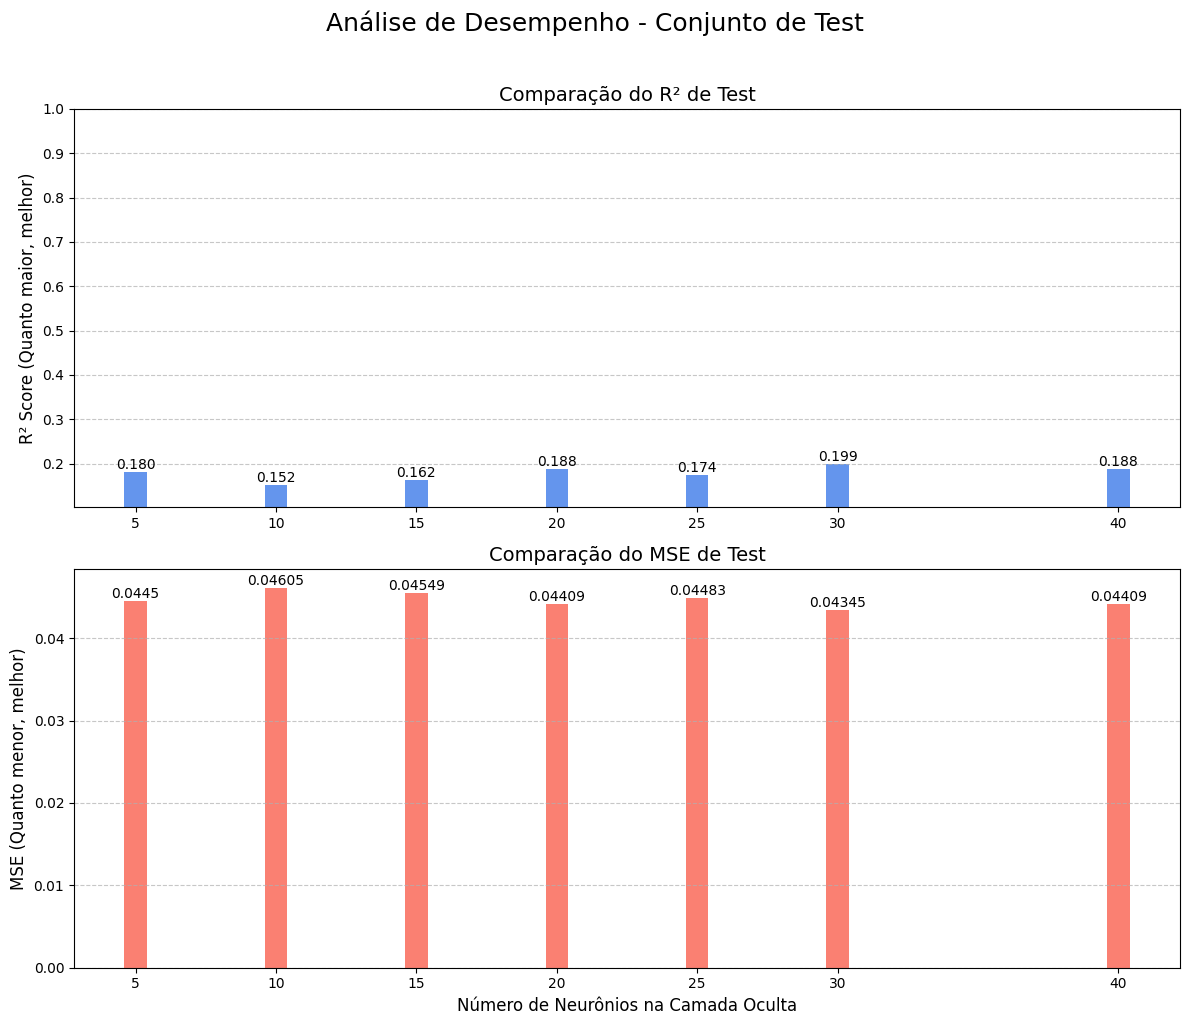

In [16]:
def print_metriscs(metrics):
    """
    Imprime as métricas de um modelo.
    """
    print("\nMétricas do modelo:")
    for split, m in metrics.items():
        print(f"\n{split} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4g}")

def plot_model_comparison(metrics_dict, data_split='Test'):
    """
    Cria gráficos de barras comparando o R2 e o MSE para um determinado
    conjunto de dados (Train, Validation ou Test).

    Args:
        metrics_dict (dict): Dicionário com os resultados dos modelos.
        data_split (str): O conjunto de dados a ser plotado. 
                          Valores válidos: 'Train', 'Validation', 'Test'.
                          O padrão é 'Test'.
    """
    try:
        # Extrai os dados para plotagem usando a chave 'data_split'
        units = list(metrics_dict.keys())
        r2_scores = [metrics[data_split]['R2'] for metrics in metrics_dict.values()]
        mse_scores = [metrics[data_split]['MSE'] for metrics in metrics_dict.values()]
    except KeyError:
        print(f"Erro: A chave '{data_split}' não foi encontrada nos dicionários de métricas.")
        print(f"Chaves disponíveis: {list(next(iter(metrics_dict.values())).keys())}")
        return

    # Cria a figura com dois subplots
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    fig.suptitle(f'Análise de Desempenho - Conjunto de {data_split}', fontsize=18, y=1.02)

    # --- Gráfico 1: Comparação de R² ---
    bars_r2 = axs[0].bar(units, r2_scores, color='cornflowerblue')
    axs[0].set_title(f'Comparação do R² de {data_split}', fontsize=14)
    axs[0].set_ylabel('R² Score (Quanto maior, melhor)', fontsize=12)
    axs[0].set_xticks(units)
    axs[0].set_ylim(bottom=max(0, min(r2_scores) - 0.05), top=max(1.0, max(r2_scores) * 1.05))
    axs[0].grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars_r2:
        yval = bar.get_height()
        axs[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

    # --- Gráfico 2: Comparação de MSE ---
    bars_mse = axs[1].bar(units, mse_scores, color='salmon')
    axs[1].set_title(f'Comparação do MSE de {data_split}', fontsize=14)
    axs[1].set_xlabel('Número de Neurônios na Camada Oculta', fontsize=12)
    axs[1].set_ylabel('MSE (Quanto menor, melhor)', fontsize=12)
    axs[1].set_xticks(units)
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars_mse:
        yval = bar.get_height()
        axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4g}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

all_metrics = {
    5: metrics_5,
    10: metrics_10,
    15: metrics_15,
    20: metrics_20,
    25: metrics_25,
    30: metrics_30,
    40: metrics_40
}

plot_model_comparison(all_metrics, data_split='Test')
